### Phase 1: Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_curve, roc_auc_score, f1_score, 
                             precision_score, recall_score)
import lime.lime_tabular
import warnings

### Phase 2: Load and Explore Data

In [49]:
df = pd.read_csv('creditcard.csv')
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Dataset shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0

**Step 2.2: Check Data Quality**

In [50]:
print("Missing values:", df.isnull().sum().sum())
print("Data types:\n", df.dtypes)
print("Summary statistics:\n", df.describe())

Missing values: 0
Data types:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Summary statistics:
                 Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.8325

**Step 2.3: Analyze Class Distribution**

In [51]:
print("Class Distribution:")
print(df['Class'].value_counts())
print("\nPercentage:")
print(df['Class'].value_counts(normalize=True) * 100)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


**Step 2.4: Visualize Class Imbalance**

# Extract counts and percentages
counts = df['Class'].value_counts()
total = len(df)
pcts = (counts / total) * 100

labels = ['Legitimate', 'Fraud']
values = [counts[0], counts[1]]
pct_values = [pcts[0], pcts[1]]

# Setup figure with Tufte-style minimalist geometry
fig, ax = plt.subplots(figsize=(8, 2.5), dpi=150)

# Muted, purposeful color palette (subdued neutral for majority, accent for minority)
colors = ['#5A6B7C', '#D9534F']

# Horizontal bar chart for natural reading hierarchy
bars = ax.barh(labels, values, color=colors, height=0.45)

# Direct data labeling: eliminates the need for x-axis ticks & separate legends
for bar, count, pct in zip(bars, values, pct_values):
    width = bar.get_width()
    ax.annotate(
        f'{count:,}  ({pct:.2f}%)',
        xy=(width, bar.get_y() + bar.get_height() / 2),
        xytext=(8, 0),
        textcoords="offset points",
        ha='left', va='center',
        fontsize=10,
        color='#2C3E50',
        fontweight='medium'
    )

# Maximize Data-Ink: remove box spines, ticks, and background clutter
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

ax.xaxis.set_visible(False)
ax.tick_params(left=False, labelsize=11, labelcolor='#2C3E50')
ax.invert_yaxis()  # Place primary class at the top

# Title as an informative data statement
ax.set_title('Transaction Class Distribution', loc='left', fontsize=12, fontweight='bold', pad=15, color='#1A252F')

# Data
counts = df['Class'].value_counts()
labels = ['Legitimate', 'Fraud']
values = [counts[0], counts[1]]
total = sum(values)

# Setup figure
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

# Muted, functional colors (avoid harsh primaries)
colors = ['#5A6B7C', '#D9534F']

# Plot pie with a clean white wedge border (donut style increases data-ink clarity)
wedges, _ = ax.pie(
    values,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=1.5)
)

# Custom leader lines & annotations to prevent overlap
for i, wedge in enumerate(wedges):
    # Calculate slice angle
    angle = (wedge.theta2 - wedge.theta1) / 2.0 + wedge.theta1
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))
    
    # Text formatting: count + percentage
    pct = (values[i] / total) * 100
    label_text = f"{labels[i]}\n{values[i]:,} ({pct:.2f}%)"
    
    # Custom alignment and positioning based on slice location
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = f"angle,angleA=0,angleB={angle}"
    
    # Offset minority class slightly higher to ensure zero collision
    y_offset = y * 1.35 if i == 0 else y * 1.45 + 0.1
    x_offset = 1.35 * np.sign(x)

    ax.annotate(
        label_text,
        xy=(x * 0.8, y * 0.8),
        xytext=(x_offset, y_offset),
        horizontalalignment=horizontalalignment,
        verticalalignment='center',
        fontsize=9.5,
        color='#2C3E50',
        fontweight='medium',
        arrowprops=dict(
            arrowstyle="-",
            color="#7F8C8D",
            lw=0.8,
            connectionstyle=connectionstyle
        )
    )

# Clean title
ax.set_title("Transaction Distribution", loc="center", fontsize=12, fontweight="bold", pad=20, color="#1A252F")

plt.tight_layout()
plt.show()

**Step 2.5: Analyze Transaction Amounts**

In [52]:
print("Legitimate Transactions Amount Statistics:")
print(df[df['Class']==0]['Amount'].describe())

print("\nFraudulent Transactions Amount Statistics:")
print(df[df['Class']==1]['Amount'].describe())

Legitimate Transactions Amount Statistics:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraudulent Transactions Amount Statistics:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


**Step 2.6: Feature Correlation**

In [53]:
correlation = df.corr()['Class'].sort_values(ascending=False)
print("Top Features Correlated with Fraud:")
print(correlation.head(10))

Top Features Correlated with Fraud:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64


### Phase 3: Data Preprocessing

**Step 3.1: Separate Features and Target**

In [54]:
X = df.drop('Class', axis=1)  # Features
y = df['Class']                # Target
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


**Step 3.2: Train-Test Split (CRITICAL: SPLIT BEFORE SCALING)**

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,         # 80-20 split
    random_state=42,       # For reproducibility
    stratify=y             # Maintain class ratio in both sets
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("Train fraud ratio:", y_train.sum()*100/ len(y_train),"%")
print("Test fraud ratio:", y_test.sum()*100/ len(y_test),'%')

Training set size: 227845
Test set size: 56962
Train fraud ratio: 0.17292457591783889 %
Test fraud ratio: 0.17204452090867595 %


**Step 3.3: Scale Features (FIT ON TRAINING ONLY)**

In [56]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training
X_test_scaled = scaler.transform(X_test)        # Transform test

# Verify scaling
print("Scaled training data mean:", X_train_scaled.mean())
print("Scaled training data std:", X_train_scaled.std())

Scaled training data mean: -6.661191966396339e-18
Scaled training data std: 1.0


**Step 3.4: Convert to DataFrame**

In [57]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

### Phase 4: Train Models

**Step 4.1: Create Evaluation Function**

In [58]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2 * (precision * recall) / (precision + recall)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    print(f"\n{name}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    
    return {
        'name': name,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'model': model,
        'predictions': y_pred,
        'probabilities': y_proba
    }

**Step 4.2: Train Logistic Regression**

In [59]:
print("Training Logistic Regression...")
lr_result = evaluate_model(
    LogisticRegression(class_weight='balanced', max_iter=1000),
    X_train_scaled, X_test_scaled, y_train, y_test,
    "Logistic Regression"
)

Training Logistic Regression...

Logistic Regression
Precision: 0.0610
Recall: 0.9184
F1-Score: 0.1144
ROC-AUC: 0.9721


**Step 4.3: Train Decision Tree**

In [60]:
print("\nTraining Decision Tree...")
dt_result = evaluate_model(
    DecisionTreeClassifier(class_weight='balanced', max_depth=10),
    X_train_scaled, X_test_scaled, y_train, y_test,
    "Decision Tree"
)


Training Decision Tree...

Decision Tree
Precision: 0.1318
Recall: 0.7857
F1-Score: 0.2258
ROC-AUC: 0.8915


**Step 4.4: Train Random Forest**

In [61]:
print("\nRandom Forest...")
rf_result = evaluate_model(
    RandomForestClassifier(
        n_estimators=100, 
        class_weight='balanced',
        max_depth=15,
        n_jobs=-1
    ),
    X_train_scaled, X_test_scaled, y_train, y_test,
    "Random Forest"
)


Random Forest...

Random Forest
Precision: 0.8966
Recall: 0.7959
F1-Score: 0.8432
ROC-AUC: 0.9641


**Step 4.5: Train SVM**

In [62]:
print("\nTraining Support Vector Machine...")
svm_result = evaluate_model(
    SVC(kernel='rbf', probability=True, class_weight='balanced'),
    X_train_scaled, X_test_scaled, y_train, y_test,
    "Support Vector Machine"
)


Training Support Vector Machine...

Support Vector Machine
Precision: 0.3217
Recall: 0.7551
F1-Score: 0.4512
ROC-AUC: 0.9732


### Phase 5: Compare Models

In [63]:
results_list = [lr_result, dt_result, rf_result, svm_result]
comparison_df = pd.DataFrame([
    {
        'Model': r['name'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1'],
        'ROC-AUC': r['roc_auc']
    }
    for r in results_list
])

print("\nModel Comparison:")
print(comparison_df.to_string())


Model Comparison:
                    Model  Precision    Recall  F1-Score   ROC-AUC
0     Logistic Regression   0.060976  0.918367  0.114358  0.972083
1           Decision Tree   0.131849  0.785714  0.225806  0.891475
2           Random Forest   0.896552  0.795918  0.843243  0.964125
3  Support Vector Machine   0.321739  0.755102  0.451220  0.973191


**Step 5.2: Visualize Confusion Matrices**

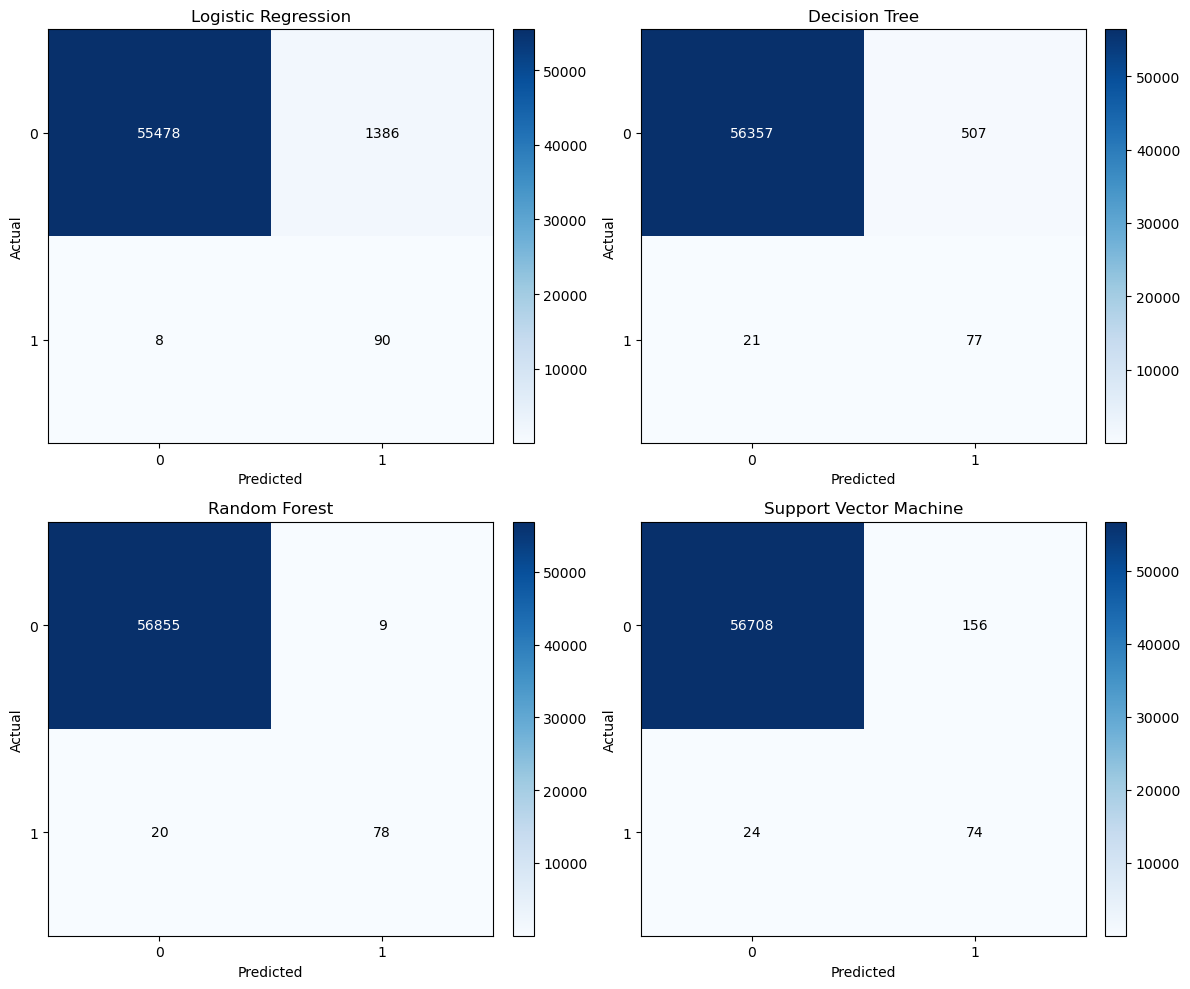

In [66]:

n_results = len(results_list)
ncols = 2
nrows = int(np.ceil(n_results / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.array(axes).flatten()  # works even if nrows*ncols == 1

for idx, result in enumerate(results_list):
    cm = confusion_matrix(y_test, result['predictions'])
    ax = axes[idx]

    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_title(result['name'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))

    # Threshold-based text color so numbers stay readable on light AND dark cells
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = 'white' if cm[i, j] > thresh else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center', color=color)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Hide any unused subplot axes (e.g., 3 results in a 2x2 grid)
for idx in range(n_results, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

**Step 5.3: Plot ROC Curves**

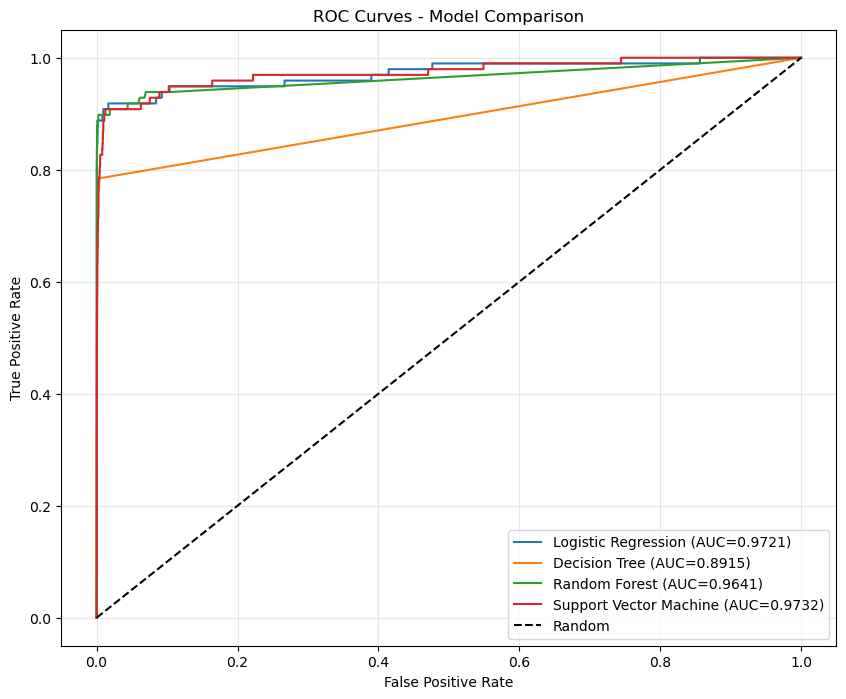

In [67]:
plt.figure(figsize=(10, 8))

for result in results_list:
    fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
    plt.plot(fpr, tpr, label=f"{result['name']} (AUC={result['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Phase 6: Hyperparameter Tuning (1 hour)

In [73]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Starting Grid Search...")
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best F1-Score (CV): {grid_search.best_score_:.4f}")

# Evaluate on test set
y_pred_tuned = grid_search.predict(X_test_scaled)
y_proba_tuned = grid_search.predict_proba(X_test_scaled)[:, 1]

print(f"\nTest Set Performance:")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_tuned):.4f}")

Starting Grid Search...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best F1-Score (CV): 0.8395

Test Set Performance:
Precision: 0.8953
Recall: 0.7857
F1-Score: 0.8370
ROC-AUC: 0.9624


### Phase 7: Feature Importance (30 minutes)

**Step 7.1: Extract Feature Importance**

In [74]:
best_model = grid_search.best_estimator_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 15 Features:")
print(feature_importance.head(15))

Top 15 Features:
   Feature  Importance
14     V14    0.184646
10     V10    0.108571
4       V4    0.102431
12     V12    0.098756
17     V17    0.089984
3       V3    0.069470
11     V11    0.055379
16     V16    0.037492
2       V2    0.036616
9       V9    0.025913
7       V7    0.021873
21     V21    0.017132
19     V19    0.014311
8       V8    0.012867
18     V18    0.012704


**Step 7.2: Visualize Feature Importance**

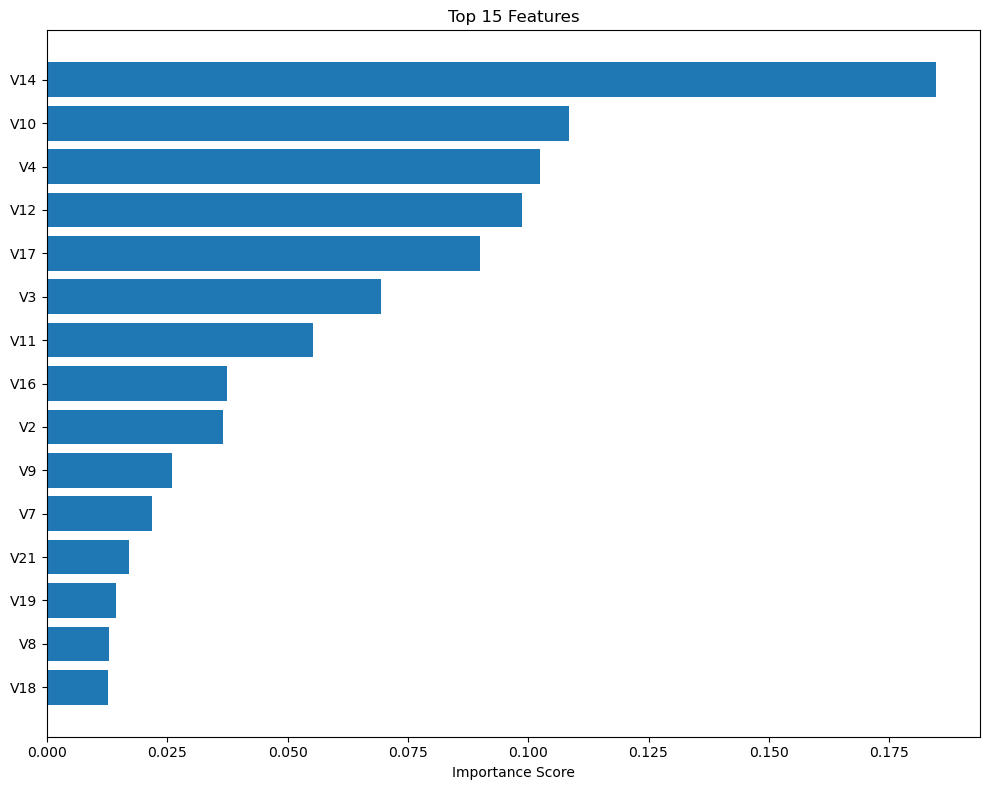

In [75]:
plt.figure(figsize=(10, 8))

top_n = 15
top_features = feature_importance.head(top_n)

plt.barh(range(top_n), top_features['Importance'])
plt.yticks(range(top_n), top_features['Feature'])
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Phase 8: LIME Explanations (45 minutes)

**Step 8.1: Initialize LIME Explainer**

In [77]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled.values,
    feature_names=X.columns.tolist(),
    class_names=['Legitimate', 'Fraud'],
    mode='classification'
)

**Step 8.2: Explain Fraudulent Transactions**

In [80]:
# Find fraud examples
# Fix your scaling step to retain the original index labels
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), 
    columns=X_test.columns, 
    index=X_test.index  # <-- Crucial fix! Keeps the original labels like 77348
)

fraud_indices = y_test[y_test == 1].index.tolist()

print("Explaining 3 Fraudulent Transactions:\n")

for i in range(3):
    fraud_idx = fraud_indices[i]
    fraud_instance = X_test_scaled.loc[fraud_idx].values
    
    explanation = explainer.explain_instance(
        fraud_instance,
        best_model.predict_proba,
        num_features=10
    )
    
    pred_fraud_prob = best_model.predict_proba([fraud_instance])[0, 1]
    
    print(f"\nFraud Transaction {i+1}")
    print(f"Fraud Probability: {pred_fraud_prob:.2%}")
    print("Top Contributing Features:")
    
    for feature, weight in explanation.as_list()[:5]:
        print(f"  {feature}: {weight:.4f}")

Explaining 3 Fraudulent Transactions:


Fraud Transaction 1
Fraud Probability: 99.99%
Top Contributing Features:
  V4 > 0.52: 0.0106
  V14 <= -0.45: 0.0067
  V17 <= -0.57: 0.0062
  V12 <= -0.41: 0.0058
  V10 <= -0.49: 0.0040

Fraud Transaction 2
Fraud Probability: 98.99%
Top Contributing Features:
  V4 > 0.52: 0.0109
  V14 <= -0.45: 0.0074
  V12 <= -0.41: 0.0054
  V17 <= -0.57: 0.0054
  V3 <= -0.59: 0.0040

Fraud Transaction 3
Fraud Probability: 93.94%
Top Contributing Features:
  V4 > 0.52: 0.0102
  V14 <= -0.45: 0.0062
  V17 <= -0.57: 0.0059
  V12 <= -0.41: 0.0058
  V10 <= -0.49: 0.0051


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warni

**Step 8.3: Explain Legitimate Transactions**

In [81]:
# Find legitimate examples
legit_indices = y_test[y_test == 0].index.tolist()

print("\nExplaining 3 Legitimate Transactions:\n")

for i in range(3):
    legit_idx = legit_indices[i*1000]  # Space them out
    legit_instance = X_test_scaled.loc[legit_idx].values
    
    explanation = explainer.explain_instance(
        legit_instance,
        best_model.predict_proba,
        num_features=10
    )
    
    pred_fraud_prob = best_model.predict_proba([legit_instance])[0, 1]
    
    print(f"\nLegitimate Transaction {i+1}")
    print(f"Fraud Probability: {pred_fraud_prob:.2%}")
    print("Top Contributing Features:")
    
    for feature, weight in explanation.as_list()[:5]:
        print(f"  {feature}: {weight:.4f}")


Explaining 3 Legitimate Transactions:


Legitimate Transaction 1
Fraud Probability: 0.00%
Top Contributing Features:
  V17 <= -0.57: 0.0049
  V4 <= -0.60: -0.0043
  V3 <= -0.59: 0.0024
  V11 <= -0.75: -0.0020
  0.05 < V14 <= 0.51: -0.0019

Legitimate Transaction 2
Fraud Probability: 0.43%
Top Contributing Features:
  V4 > 0.52: 0.0082
  V10 <= -0.49: 0.0026
  V3 <= -0.59: 0.0025
  -0.45 < V14 <= 0.05: -0.0017
  V17 > 0.47: -0.0008

Legitimate Transaction 3
Fraud Probability: 0.00%
Top Contributing Features:
  V17 <= -0.57: 0.0041
  0.14 < V12 <= 0.62: -0.0020
  Amount > -0.04: 0.0013
  V8 > 0.28: -0.0013
  -0.45 < V14 <= 0.05: -0.0010


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warni

### Phase 9: Summary and Conclusions

**Step 9.1: Generate Summary Report**

In [76]:
print("="*80)
print("FRAUD DETECTION PROJECT - SUMMARY REPORT")
print("="*80)

print("\n1. PROBLEM CONTEXT")
print(f"   - Total transactions: {len(df):,}")
print(f"   - Frauds: {(y==1).sum():,} ({(y==1).sum()/len(y)*100:.2f}%)")
print(f"   - Legitimate: {(y==0).sum():,} ({(y==0).sum()/len(y)*100:.2f}%)")
print(f"   - Class imbalance ratio: 577:1")

print("\n2. BEST MODEL PERFORMANCE")
best_score = comparison_df.loc[comparison_df['F1-Score'].idxmax()]
print(f"   - Model: {best_score['Model']}")
print(f"   - Precision: {best_score['Precision']:.4f} (low false alarm rate)")
print(f"   - Recall: {best_score['Recall']:.4f} (high fraud detection)")
print(f"   - F1-Score: {best_score['F1-Score']:.4f}")
print(f"   - ROC-AUC: {best_score['ROC-AUC']:.4f}")

print("\n3. TOP FRAUD INDICATORS")
for idx, row in feature_importance.head(5).iterrows():
    print(f"   - {row['Feature']}: {row['Importance']:.4f}")

print("\n4. DEPLOYMENT RECOMMENDATIONS")
print("   - Set fraud threshold at 0.5 probability")
print("   - Flag transactions >0.7 for automatic review")
print("   - Monitor model performance monthly")
print("   - Retrain quarterly with new fraud patterns")

print("\n" + "="*80)

FRAUD DETECTION PROJECT - SUMMARY REPORT

1. PROBLEM CONTEXT
   - Total transactions: 284,807
   - Frauds: 492 (0.17%)
   - Legitimate: 284,315 (99.83%)
   - Class imbalance ratio: 577:1

2. BEST MODEL PERFORMANCE
   - Model: Random Forest
   - Precision: 0.8966 (low false alarm rate)
   - Recall: 0.7959 (high fraud detection)
   - F1-Score: 0.8432
   - ROC-AUC: 0.9641

3. TOP FRAUD INDICATORS
   - V14: 0.1846
   - V10: 0.1086
   - V4: 0.1024
   - V12: 0.0988
   - V17: 0.0900

4. DEPLOYMENT RECOMMENDATIONS
   - Set fraud threshold at 0.5 probability
   - Flag transactions >0.7 for automatic review
   - Monitor model performance monthly
   - Retrain quarterly with new fraud patterns

